In [11]:
import pandas as pd
import numpy as np
from scipy.signal import correlate
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [2]:
wf_wikipedia = pd.read_csv('src/data/word_frequencies_wikipedia.csv')
wf_summaries = pd.read_csv('src/data/word_frequencies_summaries.csv')

In [3]:
wf_wikipedia

,Unnamed: 0,W,httpwww,Machine,Wayback,Population,V,History,orld,T,...,Reuters,fire,ISSN,Wii,Iraq,CNN,Death,Nintendo,Country,Philippines
0,1900s,0.010,0.007,0.004,0.004,0.004,0.004,0.003,0.003,0.003,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,1910s,0.015,0.000,0.000,0.000,0.000,0.005,0.000,0.002,0.003,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,1920s,0.012,0.002,0.000,0.000,0.000,0.002,0.002,0.000,0.003,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,1930s,0.012,0.002,0.000,0.000,0.000,0.003,0.001,0.000,0.003,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,1940s,0.013,0.000,0.000,0.000,0.000,0.002,0.000,0.002,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,1950s,0.009,0.000,0.000,0.000,0.000,0.003,0.002,0.002,0.001,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,1960s,0.006,0.001,0.000,0.000,0.000,0.003,0.002,0.000,0.001,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,1970s,0.006,0.000,0.000,0.000,0.000,0.002,0.000,0.000,0.001,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,1980s,0.007,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.001,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,1990s,0.007,0.002,0.000,0.000,0.000,0.001,0.000,0.001,0.002,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [4]:
wf_summaries

,Unnamed: 0,film,Pedro,girl,Mr,astronomers,travelers,train,Hyde,shot,...,discovers,friends,meet,kills,school,body,attempts,reveals,team,people
0,1900,0.017,0.008,0.007,0.006,0.006,0.006,0.005,0.005,0.005,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,1910,0.004,0.000,0.004,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,1920,0.004,0.000,0.002,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,1930,0.002,0.000,0.000,0.002,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,1940,0.002,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,1950,0.002,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,1960,0.003,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,1970,0.003,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,...,0.000,0.002,0.001,0.001,0.000,0.000,0.000,0.000,0.000,0.000
8,1980,0.003,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.002,0.000,0.000,0.002,0.001,0.001,0.000,0.000,0.000
9,1990,0.003,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.001,0.002,0.000,0.000,0.002,0.000,0.001,0.000,0.000,0.000


In [5]:
common_columns = set(wf_wikipedia.columns).intersection(wf_summaries.columns)

wf_wikipedia_filtered = wf_wikipedia[list(common_columns)]
wf_summaries_filtered = wf_summaries[list(common_columns)]

In [6]:
wf_summaries_filtered

,death,show,Joe,woman,Jerry,film,shows,home,years,time,group,people,become,attacks,end,Unnamed: 0,car,films
0,0.000,0.000,0.000,0.004,0.000,0.017,0.003,0.000,0.000,0.004,0.000,0.000,0.000,0.003,0.000,1900,0.000,0.003
1,0.000,0.000,0.000,0.003,0.000,0.004,0.000,0.003,0.002,0.002,0.000,0.000,0.000,0.000,0.000,1910,0.000,0.000
2,0.002,0.001,0.000,0.003,0.000,0.004,0.000,0.003,0.001,0.003,0.000,0.000,0.002,0.000,0.002,1920,0.000,0.000
3,0.000,0.002,0.000,0.002,0.000,0.002,0.000,0.003,0.001,0.002,0.000,0.000,0.001,0.000,0.000,1930,0.000,0.000
4,0.002,0.000,0.000,0.002,0.002,0.002,0.000,0.003,0.000,0.003,0.000,0.000,0.000,0.000,0.001,1940,0.000,0.000
5,0.002,0.000,0.002,0.002,0.003,0.002,0.000,0.003,0.000,0.003,0.000,0.000,0.000,0.000,0.002,1950,0.000,0.000
6,0.002,0.000,0.000,0.002,0.000,0.003,0.000,0.003,0.000,0.003,0.001,0.000,0.001,0.000,0.001,1960,0.002,0.000
7,0.002,0.000,0.000,0.002,0.000,0.003,0.000,0.003,0.001,0.003,0.001,0.000,0.001,0.000,0.001,1970,0.002,0.000
8,0.002,0.000,0.000,0.002,0.000,0.003,0.000,0.003,0.002,0.003,0.002,0.000,0.001,0.000,0.001,1980,0.002,0.000
9,0.002,0.000,0.000,0.002,0.000,0.003,0.000,0.003,0.002,0.003,0.001,0.000,0.001,0.000,0.000,1990,0.002,0.000


In [7]:
wf_wikipedia_filtered

,death,show,Joe,woman,Jerry,film,shows,home,years,time,group,people,become,attacks,end,Unnamed: 0,car,films
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.001,0.000,0.002,0.000,0.000,0.000,1900s,0.001,0.000
1,0.002,0.000,0.000,0.000,0.000,0.002,0.000,0.000,0.002,0.000,0.000,0.004,0.000,0.000,0.000,1910s,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.004,0.000,0.000,0.002,0.002,0.000,0.000,0.000,0.000,0.000,1920s,0.000,0.002
3,0.000,0.000,0.000,0.000,0.000,0.004,0.000,0.000,0.002,0.000,0.000,0.001,0.000,0.000,0.000,1930s,0.000,0.002
4,0.000,0.000,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.002,0.000,0.000,0.000,1940s,0.000,0.002
5,0.001,0.000,0.001,0.000,0.001,0.000,0.000,0.000,0.000,0.002,0.000,0.002,0.000,0.000,0.000,1950s,0.000,0.000
6,0.001,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.002,0.001,0.002,0.000,0.000,0.002,1960s,0.000,0.001
7,0.000,0.000,0.000,0.001,0.000,0.001,0.000,0.000,0.001,0.001,0.000,0.002,0.000,0.000,0.002,1970s,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.002,0.000,0.001,0.002,0.002,0.000,0.003,0.000,0.000,0.003,1980s,0.000,0.003
9,0.000,0.001,0.000,0.000,0.000,0.000,0.002,0.000,0.002,0.002,0.000,0.002,0.001,0.000,0.002,1990s,0.000,0.002


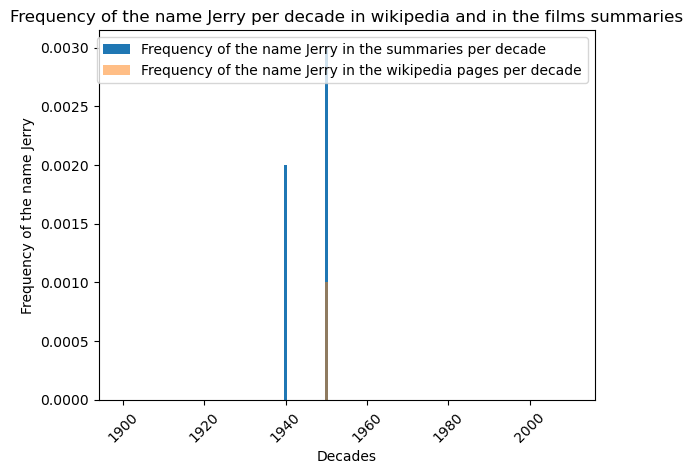

In [32]:
decade_name = [1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010]
plt.bar(decade_name,wf_summaries_filtered['Jerry'], label = 'Frequency of the name Jerry in the summaries per decade')
plt.bar(decade_name,wf_wikipedia_filtered['Jerry'], alpha = 0.5,label = 'Frequency of the name Jerry in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the name Jerry')
plt.title('Frequency of the name Jerry per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [25]:
correlation, p_value = pearsonr(wf_summaries_filtered['Jerry'], wf_wikipedia_filtered['Jerry'])
p_value

0.0011891694323429374

The name Jerry was apparently very popular in the 1940s-1950s

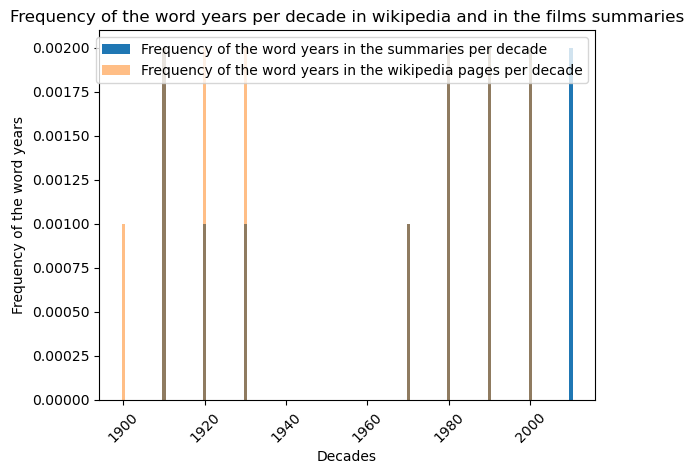

In [30]:
plt.bar(decade_name,wf_summaries_filtered['years'], label = 'Frequency of the word years in the summaries per decade')
plt.bar(decade_name,wf_wikipedia_filtered['years'], alpha = 0.5 ,label = 'Frequency of the word years in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [23]:
correlation, p_value = pearsonr(wf_summaries_filtered['years'], wf_wikipedia_filtered['years'])
p_value

0.028666826130540526

Weird but ok.....